# Objective
<b> Finding the most prevalent hosts of the Coronaviridae dataset </b>
1) make sure there are no duplicates
2) in this case, take the most prevalent classes for coronavirus then
3) take the 99.9% of sequence length. <b> use the 99.9% sequence length number we got from prev dataset </b>

In [10]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt

# Functions

In [11]:

def column_stats_new(df, id_column, name_column, tax_id_column, n=None):
    if n is None:
        n = df.shape[0]
    count_column = name_column + "_count"
    count_df = df[[name_column, tax_id_column, id_column]].groupby([name_column, tax_id_column]).count().reset_index()
    count_df.columns=[name_column, tax_id_column, count_column]
    count_df[name_column + "_percent"] = count_df[count_column].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[name_column].unique())}")
    return count_df

def column_stats(df, column_name, n=None):
    if n is None:
        n = df.shape[0]
    count_column_name = column_name + "_count"
    count_df = pd.DataFrame(df[column_name].value_counts()).reset_index()
    count_df.columns=[column_name, count_column_name]
    count_df[column_name + "_percent"] = count_df[count_column_name].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[column_name].unique())}")
    print(f"{count_df}")
    return count_df
    
def filter_with_threshold(df, column_name, threshold):
    print(f"Size of df = {df.shape}")
    n = df.shape[0]
    count_df = column_stats(df, column_name, n=n)
    percent_column_name = column_name + "_percent"
    filtered_count_df = count_df[count_df[percent_column_name] >= threshold]
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    print(f"Size of filtered df = {filtered_df.shape}") 
    column_stats(filtered_df, column_name, n=n)
    return filtered_df

In [12]:
def print_seq_len_histogram(df, n_bins):
    sns.histplot(df["seq_len"])
    print(f"min seq len = {min(df['seq_len'])}")
    print(f"max seq len = {max(df['seq_len'])}")
    plt.show()
    
    freq, bins = np.histogram(df["seq_len"], bins=n_bins)
    n = df.shape[0]
    hist_map = []
    for i in range(n_bins):
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
    hist_df = pd.DataFrame(hist_map)
    print(hist_df)

# File outputted from step 9

In [13]:
file = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata.csv")
df2 = pd.read_csv(file)
df2


column_stats(df2, "virus_host_tax_id")

Number of unique values = 119
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                    0                      128                  18.991098
1                 9606                      125                  18.545994
2                 9031                       61                   9.050445
3                 9685                       36                   5.341246
4                 9823                       19                   2.818991
..                 ...                      ...                        ...
114            1898386                        1                   0.148368
115              34924                        1                   0.148368
116            2603869                        1                   0.148368
117              58065                        1                   0.148368
118               9793                        1                   0.148368

[119 rows x 3 columns]


,virus_host_tax_id,virus_host_tax_id_count,virus_host_tax_id_percent
0,0,128,18.991098
1,9606,125,18.545994
2,9031,61,9.050445
3,9685,36,5.341246
4,9823,19,2.818991
...,...,...,...
114,1898386,1,0.148368
115,34924,1,0.148368
116,2603869,1,0.148368
117,58065,1,0.148368


In [25]:
file = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata_species_virus_host_vertebrates_w_seq.csv")
df = pd.read_csv(file)
df["seq_len"] = df["seq"].apply(lambda x: len(x))
df = df[~df.duplicated()] #Removing duplicates
output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/uniref50_validhosts.csv")
df.to_csv(output, index=False) #230 rows
df

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
0,UniRef50_A0A5J6YH13,1586324,NaN,QFP39650.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species,MQRALLIMTLLCLVRAKFADDLLDLLTFPGAHRFLHKLTSNSSSLY...,580
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species,VLPLASCFFTCNSNANLSMLQLGVPDNSSTIVTGLLPTHWICANQS...,253
2,UniRef50_A0A5P9K482,28295,NaN,QFU19298.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species,VTXGRNCLFNKAIPAHMQDGXNXVXGITWDNDRVTVFXDKIYHFYX...,491
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species,AFAVIGDLKCPLDTSRKGSFNNKDTGPPFISTDTVDVTNGLGTYYV...,272
4,UniRef50_A0A5Q0TVS7,11118,NaN,QGA70693.1,['Erinaceus amurensis'],erinaceus amurensis,Coronaviridae,family,757341,species,MQCKRLLFFIACNLLSISLAKPYIPEHCGNFEGALLQACLQSALTD...,103
...,...,...,...,...,...,...,...,...,...,...,...,...
532,UniRef50_A0A4D6FTP0,2569586,NaN,QCB65094.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species,MDETCSPEILLLKKQAQQSRLRLISLQPFIVKGPGGSWVYKFDDHE...,69
533,UniRef50_A0A4D6FTX3,2569586,NaN,QCB65098.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species,MSDDSSCCIHNPCLSEWCVYCNPPDEDVPLHVLSFIINSQQELLEL...,53
534,UniRef50_A0A4D6FWC5,694013,NaN,QCB65106.1,['Branta canadensis'],branta canadensis,Gammacoronavirus,genus,8853,species,MDMAQVVKTPLEASVKTMEARLGCGSSECEWNWSKHTNRLPLCLFS...,97
535,UniRef50_A0A4P2VDR0,136187,NaN,BBD43534.1,['Donkey'],donkey,Equine coronavirus,no rank,9793,species,AWSVDSCLQDGRCNIFSNLILNGVNSGATCSTDLQRSNTEIVVGVC...,217


In [26]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/coronaviridae_s_uniref90_embl_hosts_pruned_metadata_corrected.csv")
df.to_csv(file_path, index=False)

<b> Filtering by minimum count since dataset too small for prevalence </b>

 In the reference Jupyter notebook there should already be a function that can perform this. You can send in the column for virus host taxon id instead of name to this function and could do a minimum count of something like 20 to start.

In [27]:
print(df.shape)
host_tax_counts = column_stats(df, "virus_host_tax_id")
host_tax_counts

(530, 12)
Number of unique values = 114
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                 9606                      125                  23.584906
1                 9031                       61                  11.509434
2                 9685                       36                   6.792453
3                 9823                       19                   3.584906
4                 9612                       17                   3.207547
..                 ...                      ...                        ...
109            1898386                        1                   0.188679
110              34924                        1                   0.188679
111            2603869                        1                   0.188679
112              58065                        1                   0.188679
113               9793                        1                   0.188679

[114 rows x 3 columns]


,virus_host_tax_id,virus_host_tax_id_count,virus_host_tax_id_percent
0,9606,125,23.584906
1,9031,61,11.509434
2,9685,36,6.792453
3,9823,19,3.584906
4,9612,17,3.207547
...,...,...,...
109,1898386,1,0.188679
110,34924,1,0.188679
111,2603869,1,0.188679
112,58065,1,0.188679


Top 3 virus host tax ids:

0	9606 homo sapiens (humans) : count = 125

1	9031 gallus gallus (chicken) : count = 61

2   9685 felis catus (cat) : count = 36

In [28]:
count = df["virus_host_tax_id"].value_counts().reset_index()
print(count)

hosts = df["virus_name"].value_counts().reset_index()
print(hosts)

     virus_host_tax_id  count
0                 9606    125
1                 9031     61
2                 9685     36
3                 9823     19
4                 9612     17
..                 ...    ...
109            1898386      1
110              34924      1
111            2603869      1
112              58065      1
113               9793      1

[114 rows x 2 columns]
                                            virus_name  count
0                                        Coronaviridae     62
1      Severe acute respiratory syndrome coronavirus 2     47
2                          Infectious bronchitis virus     44
3    Middle East respiratory syndrome-related coron...     39
4                                   Feline coronavirus     27
..                                                 ...    ...
105          Rocky Mountain bat coronavirus 61/2007/EF      1
106          Rocky Mountain bat coronavirus 15/2006/ML      1
107                             Bat Coronavirus MpGD16    

In [40]:
host_tax_ids = [9606, 9031, 9685]
host_tax = {
    9606: "Homo Sapiens",
    9031: "Gallus Gallus",
    9685: "Felis Catus"
}


top = count[count["count"] >= 20]
top.loc[:, "host_name"] = top["virus_host_tax_id"].map(host_tax)
top

/localscratch/ipykernel_1191390/594875478.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top.loc[:, "host_name"] = top["virus_host_tax_id"].map(host_tax)


,virus_host_tax_id,count,host_name
0,9606,125,Homo Sapiens
1,9031,61,Gallus Gallus
2,9685,36,Felis Catus


<b> 99.9% of the sequence lengths </b>

min seq len = 13
max seq len = 7078


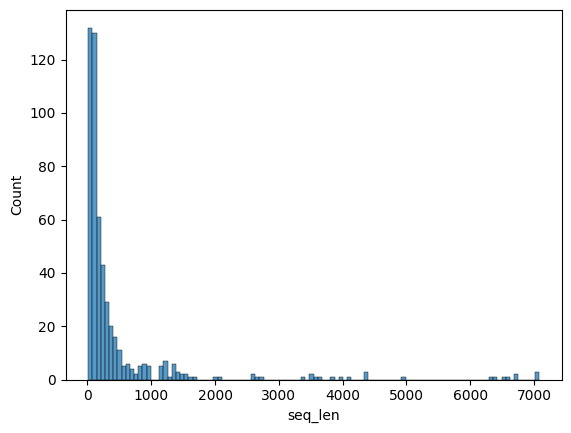

      start      end  count  percentage
0     13.00   601.75    447   84.339623
1    601.75  1190.50     33    6.226415
2   1190.50  1779.25     23    4.339623
3   1779.25  2368.00      2    0.377358
4   2368.00  2956.75      4    0.754717
5   2956.75  3545.50      3    0.566038
6   3545.50  4134.25      5    0.943396
7   4134.25  4723.00      3    0.566038
8   4723.00  5311.75      1    0.188679
9   5311.75  5900.50      0    0.000000
10  5900.50  6489.25      2    0.377358
11  6489.25  7078.00      7    1.320755


In [31]:
print_seq_len_histogram(df, 12)

<b> Sequence Length findings before filtering by minimum count </b>

Number of unique values = 111
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                 9606                      122                  23.968566
1                 9031                       60                  11.787819
2                 9685                       35                   6.876228
3                 9823                       18                   3.536346
4                 9612                       17                   3.339882
..                 ...                      ...                        ...
106             270698                        1                   0.196464
107             867834                        1                   0.196464
108             109485                        1                   0.196464
109             227184                        1                   0.196464
110               9793                        1                   0.196464

[111 rows x 3 columns]
(509, 12)
min seq len = 13
max seq len = 2717


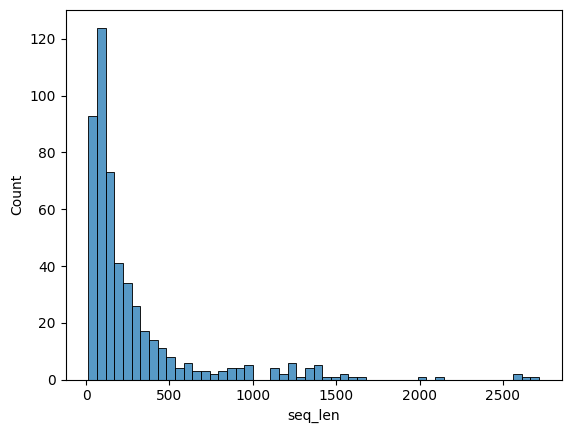

    start     end  count  percentage
0    13.0   283.4    376   73.870334
1   283.4   553.8     66   12.966601
2   553.8   824.2     19    3.732809
3   824.2  1094.6     14    2.750491
4  1094.6  1365.0     17    3.339882
5  1365.0  1635.4     10    1.964637
6  1635.4  1905.8      1    0.196464
7  1905.8  2176.2      2    0.392927
8  2176.2  2446.6      0    0.000000
9  2446.6  2717.0      4    0.785855


In [32]:
filtered = df[df["seq_len"] <= 2988]
#using the 99.9% from original entire uniref50 dataset
column_stats(filtered, "virus_host_tax_id")
print(filtered.shape)
print_seq_len_histogram(filtered, 10)

output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/coronaviridae_seq_len.csv")
filtered.to_csv(output_file_path, index=False)

In [33]:
column_stats(filtered, "virus_name")

Number of unique values = 108
                                            virus_name  virus_name_count  \
0                                        Coronaviridae                58   
1      Severe acute respiratory syndrome coronavirus 2                47   
2                          Infectious bronchitis virus                43   
3    Middle East respiratory syndrome-related coron...                36   
4                                   Feline coronavirus                27   
..                                                 ...               ...   
103                             Rm-Bat-CoV 453/2007/EF                 1   
104          Rocky Mountain bat coronavirus 61/2007/EF                 1   
105          Rocky Mountain bat coronavirus 15/2006/ML                 1   
106                             Bat Coronavirus MpGD16                 1   
107                                   Gammacoronavirus                 1   

     virus_name_percent  
0             11.394892  
1    

,virus_name,virus_name_count,virus_name_percent
0,Coronaviridae,58,11.394892
1,Severe acute respiratory syndrome coronavirus 2,47,9.233792
2,Infectious bronchitis virus,43,8.447937
3,Middle East respiratory syndrome-related coron...,36,7.072692
4,Feline coronavirus,27,5.304519
...,...,...,...
103,Rm-Bat-CoV 453/2007/EF,1,0.196464
104,Rocky Mountain bat coronavirus 61/2007/EF,1,0.196464
105,Rocky Mountain bat coronavirus 15/2006/ML,1,0.196464
106,Bat Coronavirus MpGD16,1,0.196464


<b> Filtered information about the top 5 virus hosts </b>

In [34]:
saved_df = column_stats(filtered, "virus_host_tax_id")
saved_df

output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/filtered_seq_df")
saved_df.to_csv(output, index=False)

Number of unique values = 111
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                 9606                      122                  23.968566
1                 9031                       60                  11.787819
2                 9685                       35                   6.876228
3                 9823                       18                   3.536346
4                 9612                       17                   3.339882
..                 ...                      ...                        ...
106             270698                        1                   0.196464
107             867834                        1                   0.196464
108             109485                        1                   0.196464
109             227184                        1                   0.196464
110               9793                        1                   0.196464

[111 rows x 3 columns]


# Final Dataframe used for Fine-Tuning
<b> Top 3 hosts, prevalence of at least 20 appearances </b>

In [35]:
filtered.loc[:, "virus_host_tax_id_count"] = (
    filtered.groupby("virus_host_tax_id")["virus_host_tax_id"]
    .transform("count"))
filtered
entire = filtered[filtered["virus_host_tax_id_count"] >= 20]
final = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/coronaviridae/20250616/final_filtered_df.csv")
entire.to_csv(final, index = False)
entire

/localscratch/ipykernel_1191390/3133738625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered.loc[:, "virus_host_tax_id_count"] = (


,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len,virus_host_tax_id_count
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species,VLPLASCFFTCNSNANLSMLQLGVPDNSSTIVTGLLPTHWICANQS...,253,122
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species,AFAVIGDLKCPLDTSRKGSFNNKDTGPPFISTDTVDVTNGLGTYYV...,272,122
8,UniRef50_A0A5Q2USU7,11120,NaN,QGH51289.1,['Gallus gallus'],gallus gallus,Infectious bronchitis virus,no rank,9031,species,MLKKSLFLVTILCALCSANLFDPANTYVYYYQSAFKPPNGWPPRGG...,280,60
9,UniRef50_A0A0K0Q056,694014,NaN,AKR04371.1,['chicken'],chicken,Avian coronavirus,species,9031,species,DVIFCDGSPRGLLSCQNNTGNFKNGWYPIINTSLVKEKFVVYRETL...,148,60
10,UniRef50_A0A5Q2UT18,694014,NaN,QGH51290.1,['Gallus gallus'],gallus gallus,Avian coronavirus,species,9031,species,YLVKSLFLVTLSFALCSANLYNDSYVYYYQSAFRPPTGSRVRGGAY...,122,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,UniRef50_W6A976,1335626,NaN,AHI48785.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species,YFTLGCKILTLTPRNKWSGVSDLSLKQKLLYTFYGKESLENPTYIY...,315,122
520,UniRef50_N1NTJ5,12663,NaN,CCW59376.1,['Felis catus'],felis catus,Feline coronavirus,no rank,9685,species,AQAAVINDEIVGAITAVNQTDLFEFVNHTQSRRSRRSASSSVTTYT...,52,35
522,UniRef50_X5CNV6,694014,NaN,AHW48920.1,['chicken'],chicken,Avian coronavirus,species,9031,species,NTTLKLTNFTFTNVSNASPNSGGVHTFQLYQTSTAQNGYYNFNFSF...,83,60
525,UniRef50_X5D4P7,11120,NaN,AHW49209.1,['chicken'],chicken,Infectious bronchitis virus,no rank,9031,species,YRVVNTTNLTASTCSLGGVPNLVEVNTPAVTIASPSRLPWSKANFT...,174,60


# Findings

<b> Filters placed: </b>

* minimum host tax id count of 20
* minimum sequence length of 2988 (based on 99.9% from entire uniref50 dataset)
* this brought the dataset down from 530 to 217

<b> the top 3 hosts </b>

* 9606	: 125	Homo Sapiens
* 9031	: 61	Gallus Gallus
* 9685	: 36	Felis Catus


<b> Sequence Length after filtering by minimum count of 20 </b>

min seq len = 14
max seq len = 2582


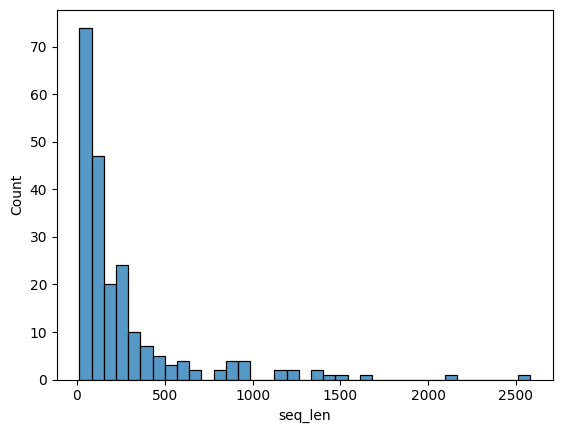

     start     end  count  percentage
0     14.0   228.0    143   65.898618
1    228.0   442.0     39   17.972350
2    442.0   656.0     13    5.990783
3    656.0   870.0      5    2.304147
4    870.0  1084.0      6    2.764977
5   1084.0  1298.0      4    1.843318
6   1298.0  1512.0      4    1.843318
7   1512.0  1726.0      1    0.460829
8   1726.0  1940.0      0    0.000000
9   1940.0  2154.0      1    0.460829
10  2154.0  2368.0      0    0.000000
11  2368.0  2582.0      1    0.460829


In [36]:
final_histogram = print_seq_len_histogram(entire, 12)

# Generating Pie Chart showing Host Distributions

In [37]:
host_tax_ids = [9606, 9031, 9685]
host_tax = {
    9606: "Homo Sapiens",
    9031: "Gallus Gallus",
    9685: "Felis Catus"
}

In [38]:
host_counts = entire['virus_host_tax_id'].value_counts()
filtered_counts = host_counts[host_counts.index.isin(host_tax.keys())]
filtered_counts.index = filtered_counts.index.map(host_tax)

<Figure size 800x600 with 0 Axes>

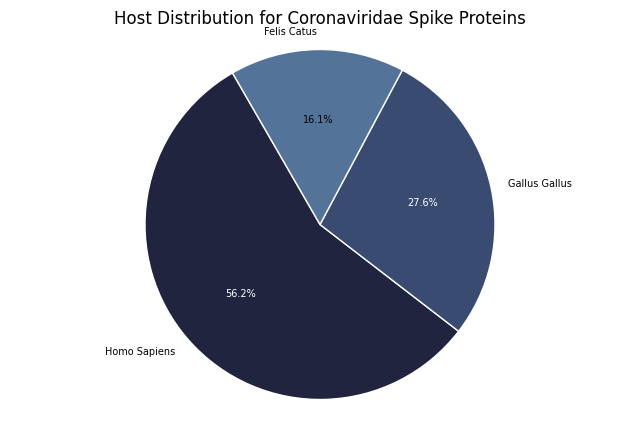

In [39]:
plt.figure(figsize=(8, 6))

fig, ax = plt.subplots(figsize = (8,5))
wedges, texts, autotexts = ax.pie(
    
    filtered_counts,
    labels = filtered_counts.index,
    autopct = '%1.1f%%',
    startangle = 120,
    colors = sns.cubehelix_palette(rot=-0.2, reverse = True),
    wedgeprops = {"edgecolor": "white"},
    textprops = {"fontsize": 7}
)
for i, autotext in enumerate(autotexts):
    facecolor = wedges[i].get_facecolor()[:3]  # RGB
    brightness = sum(facecolor)  # crude brightness check
    if brightness < 1.2:  # dark background
        autotext.set_color("white")
plt.title('Host Distribution for Coronaviridae Spike Proteins')
plt.axis('equal')

figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/uniref50/distribtion_piechart.pdf")
plt.savefig(figure_output_filepath, dpi=600)
plt.show()